# Analisis Sentimen Review Aplikasi Blibli Menggunakan Support Vector Machine (SVM)

In [49]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
import pandas as pd

In [51]:
df = pd.read_csv('/content/drive/MyDrive/hasil_scraping_blibli.csv')

## 1. Pengumpulan dan Pembacaan Dataset

In [52]:
df = df[['content', 'score']]

df.head()

,content,score
0,Blibli offers a premium shopping experience wi...,5
1,"eror terus tidak dapat mendaftar atau login,to...",1
2,baru nyoba nanti kalo cepat pengiriman nya tam...,4
3,€ Alhamdulillah dapat saldo di shopeepay 5juta...,5
4,"mantap, saya suka interface nya",5


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  1200 non-null   object
 1   score    1200 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 18.9+ KB


## 2. Labeling Sentimen

In [54]:
def sentiment(score):
    if score >= 4:
        return 'Positif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Negatif'

df['sentiment'] = df['score'].apply(sentiment)

In [55]:
df['sentiment'].value_counts()

,count
sentiment,
Positif,798
Negatif,367
Netral,35


In [56]:
!pip install nltk wordcloud

## 3. Text Preprocessing
Tahapan preprocessing meliputi:
- Case Folding
- Cleaning
- Stopword Removal

In [57]:
import re
import nltk

from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('indonesian'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [58]:
import re

def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

In [59]:
df['clean_text'] = df['content'].apply(preprocess)

In [60]:
df[['content', 'clean_text']].head()

,content,clean_text
0,Blibli offers a premium shopping experience wi...,blibli offers a premium shopping experience wi...
1,"eror terus tidak dapat mendaftar atau login,to...",eror mendaftar logintolong dibantu
2,baru nyoba nanti kalo cepat pengiriman nya tam...,nyoba kalo cepat pengiriman nya bintang
3,€ Alhamdulillah dapat saldo di shopeepay 5juta...,alhamdulillah saldo shopeepay juta kode referr...
4,"mantap, saya suka interface nya",mantap suka interface nya


## 4. Distribusi Sentimen

In [61]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()



## 5. Visualisasi Sentimen

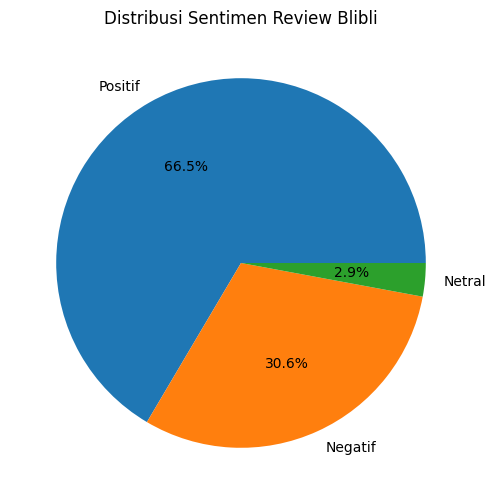

In [62]:
plt.figure(figsize=(6,6))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribusi Sentimen Review Blibli')
plt.show()

### 5.1 WordCloud Sentimen Positif

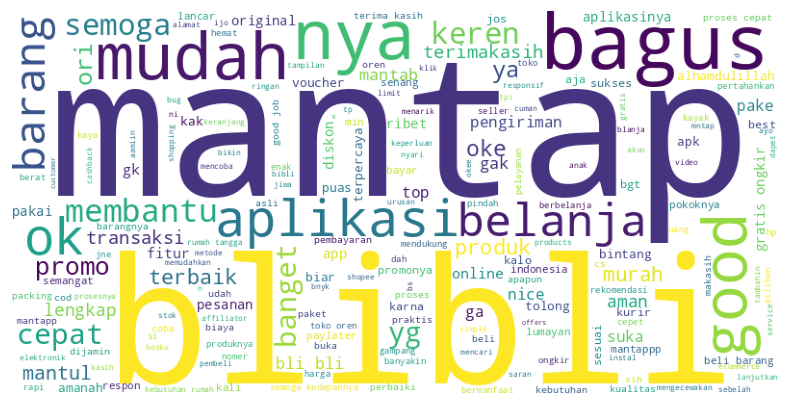

In [63]:


# WordCloud Positif
from wordcloud import WordCloud

positive_text = " ".join(
    df[df['sentiment']=='Positif']['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()


### 5.2 WordCloud Sentimen Negatif

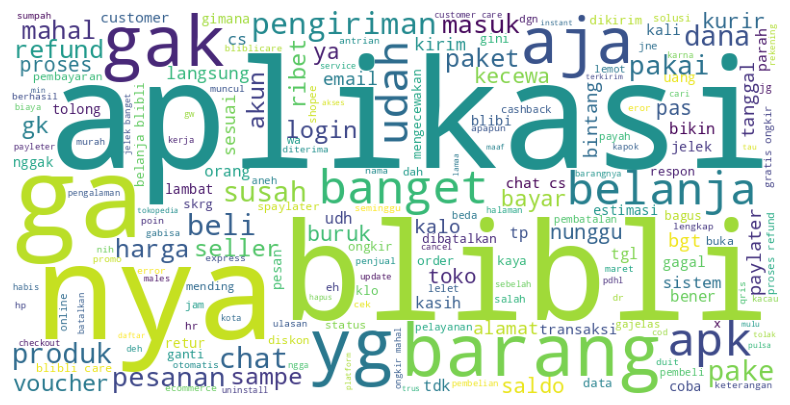

In [64]:
# WordCloud Negatif
negative_text = " ".join(
    df[df['sentiment']=='Negatif']['clean_text']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

## 5.3 Diagram Batang Distribusi Sentimen

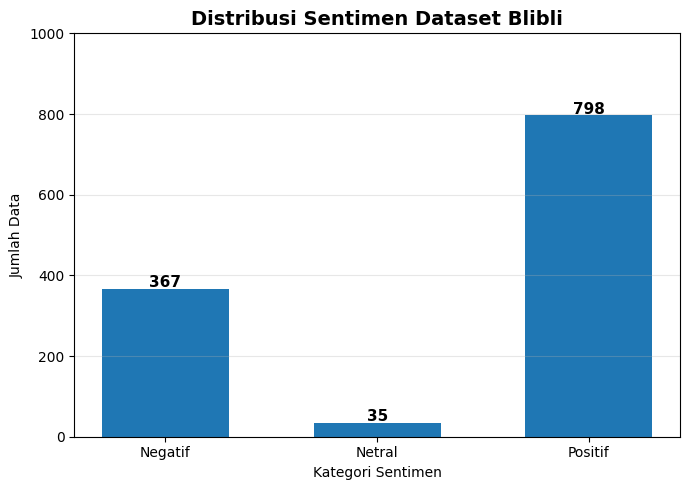

In [65]:
import matplotlib.pyplot as plt

sentiment_count = df['sentiment'].value_counts()

sentiment_count = sentiment_count[['Negatif','Netral','Positif']]

plt.figure(figsize=(7,5))

bars = plt.bar(
    sentiment_count.index,
    sentiment_count.values,
    width=0.6
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+3,
        str(int(bar.get_height())),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Distribusi Sentimen Dataset Blibli", fontsize=14, fontweight='bold')
plt.xlabel("Kategori Sentimen")
plt.ylabel("Jumlah Data")
plt.ylim(0,1000)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Ekstraksi Fitur Menggunakan TF-IDF
TF-IDF digunakan untuk mengubah data teks menjadi representasi numerik yang dapat diproses oleh algoritma machine learning.

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

## 7. Pembagian Data Training dan Testing

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 8. Training Model Support Vector Machine (SVM)

In [68]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

LinearSVC()

## 9. Evaluasi Model

In [69]:
from sklearn.metrics import accuracy_score

y_pred = svm_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.8458333333333333


In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Negatif       0.79      0.75      0.77        73
      Netral       0.00      0.00      0.00         7
     Positif       0.87      0.93      0.90       160

    accuracy                           0.85       240
   macro avg       0.55      0.56      0.56       240
weighted avg       0.82      0.85      0.83       240



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 9.1 Confusion Matrix

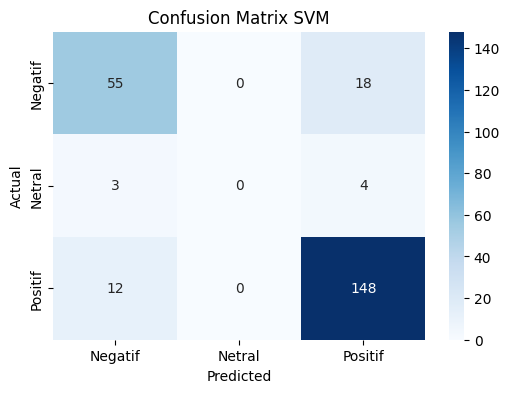

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negatif','Netral','Positif'],
    yticklabels=['Negatif','Netral','Positif']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix SVM')
plt.show()

## 10. Penyimpanan Model

In [74]:
import joblib

joblib.dump(svm_model, '/content/drive/MyDrive/svm_model.pkl')
joblib.dump(tfidf, '/content/drive/MyDrive/tfidf_vectorizer.pkl')

['/content/drive/MyDrive/tfidf_vectorizer.pkl']